**PROJECT**

Based upon data of employees of a bank we calculate whether an employee stands a chance to stay in the company or not.

----------------------------------------------------------------------------------------------------------------
**STEP 1: IMPORT LIBRARIES**

In [89]:
#let's start importing the first libraries we'll need to use
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [90]:
#read the csv and see at least the very first rows to get an idea of it
emp = pd.read_csv('Churn_Modelling.csv')
emp.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [91]:
emp.dtypes

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [92]:
emp_flag = emp[["HasCrCard","IsActiveMember","Exited"]]
emp_cat = emp[["CustomerId","Surname","Geography","Gender"]]
emp_num = emp[["CreditScore","Age","Tenure","Balance","NumOfProducts","EstimatedSalary"]]
emp_num.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,100090.239881
std,96.653299,10.487806,2.892174,62397.405202,0.581654,57510.492818
min,350.000000,18.000000,0.000000,0.000000,1.000000,11.580000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,51002.110000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,100193.915000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,149388.247500
max,850.000000,92.000000,10.000000,250898.090000,4.000000,199992.480000


---------------------------------------------------------------------------------------------------------------
**STEP 2: EXPLORATORY DATA ANALYSIS**

In [113]:
#I want tosee how many exited employees there are per country
conteggio_exited = emp.groupby('Geography')['Exited'].sum()
conteggio_exited

Geography
France     810
Germany    814
Spain      413
Name: Exited, dtype: int64

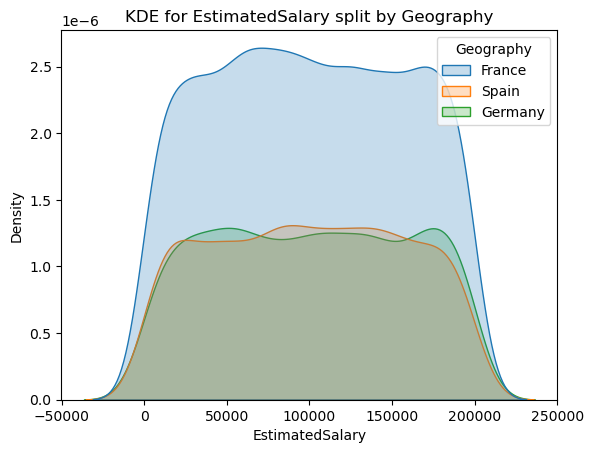

In [93]:
sns.kdeplot(data=emp, x="EstimatedSalary", hue="Geography", fill=True)
plt.title(f'KDE for EstimatedSalary split by Geography')
plt.show()

Even though the highest salaries are in France, here there is the second highest number of exited employees.

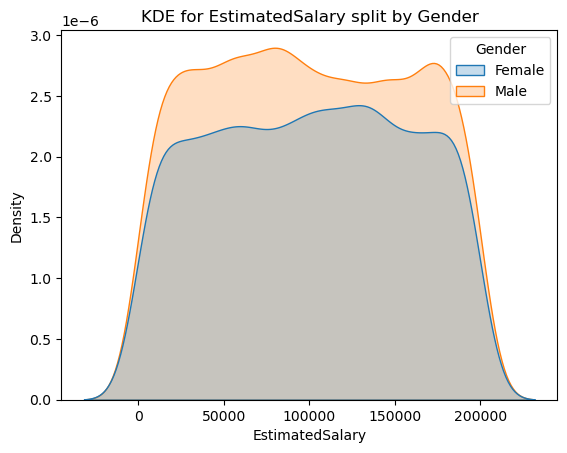

In [94]:
sns.kdeplot(data=emp, x="EstimatedSalary", hue="Gender", fill=True)
plt.title(f'KDE for EstimatedSalary split by Gender')
plt.show()

Ok, we've seen the distribution of the expected salary split by both gender and country. Let's see other distributions as well.

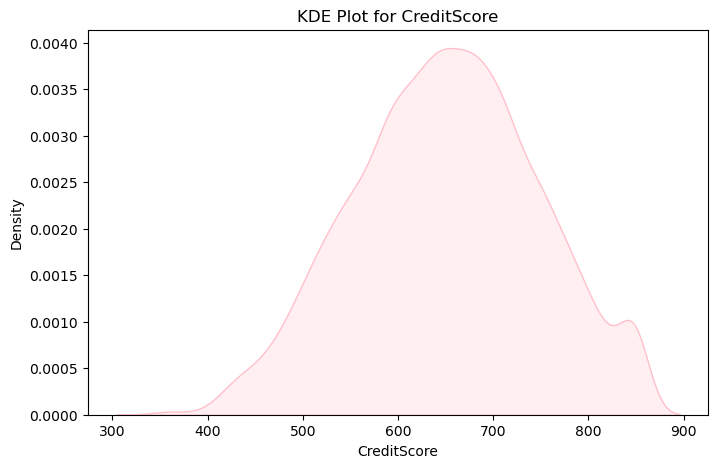

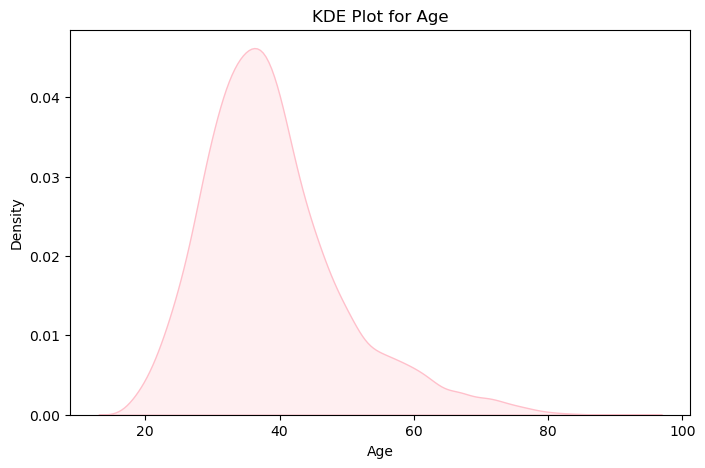

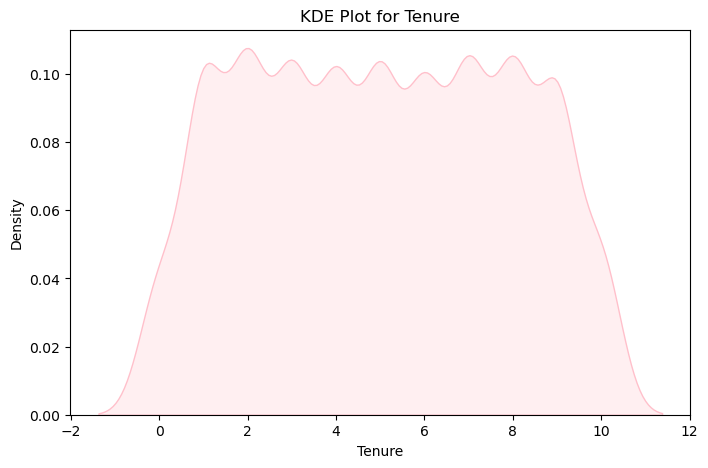

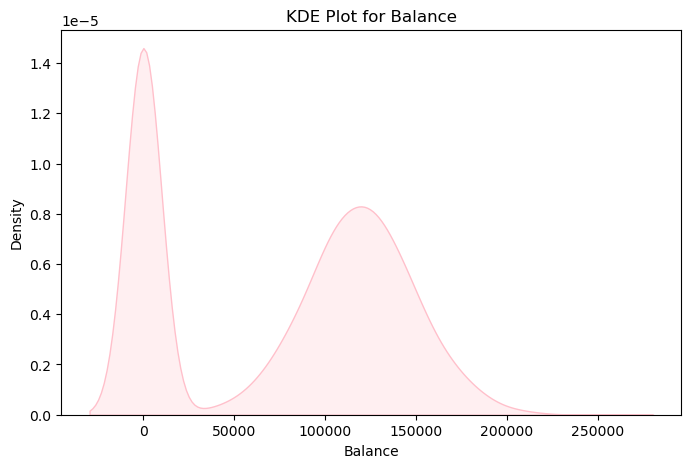

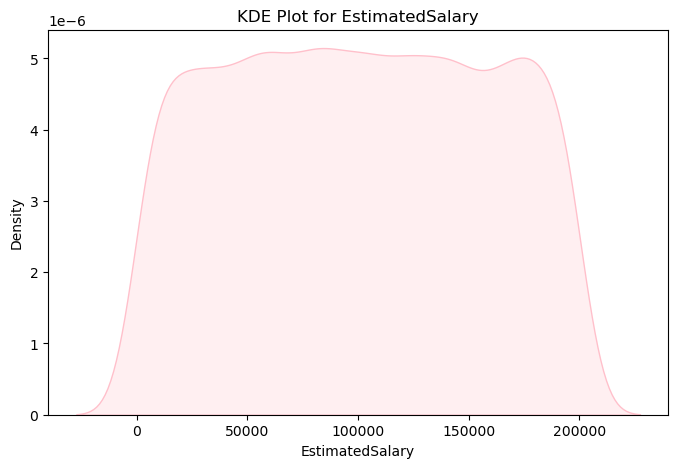

In [95]:
numcol=['CreditScore','Age','Tenure','Balance','EstimatedSalary']
for col in numcol:
    plt.figure(figsize=(8, 5))  # Create a new figure for each plot
    sns.kdeplot(emp[col], color='pink', fill=True)
    plt.title(f'KDE Plot for {col}')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.show()  # Display the plot and close it before the next one

The **EstimatedSalary** seems to follow an *uniform distribution*.

The **Balance** seems to follow a *bimodal distribution*.

The **Tenure** seems to follow an *uniform distribution*.

The **Age** seems to follow a *Poisson distribution*.

The **CreditScore** seems to follow a *t-student distribution*.

Questions we need to wonder about:
Are there **outliers**? 
Are there **missing values**?

For outliers let's do some boxplots

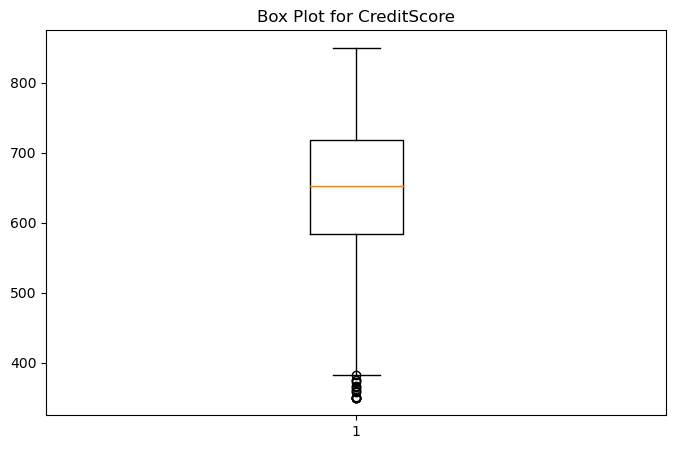

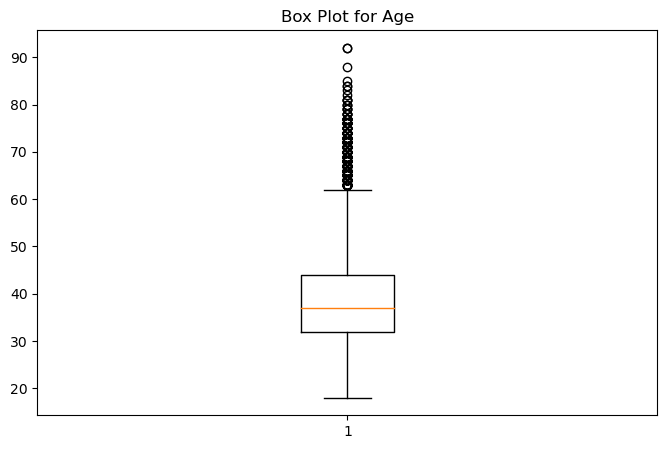

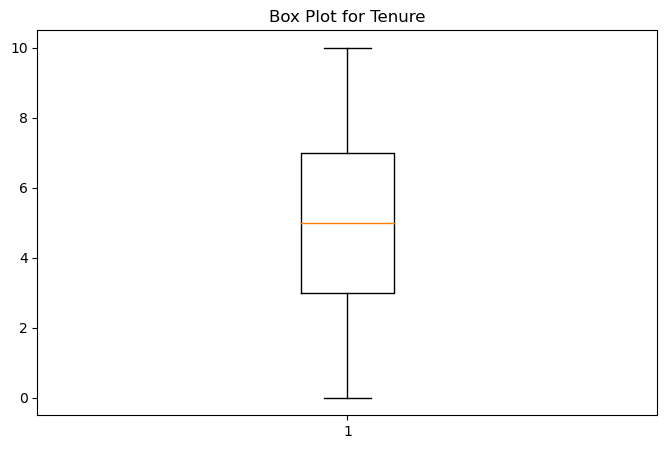

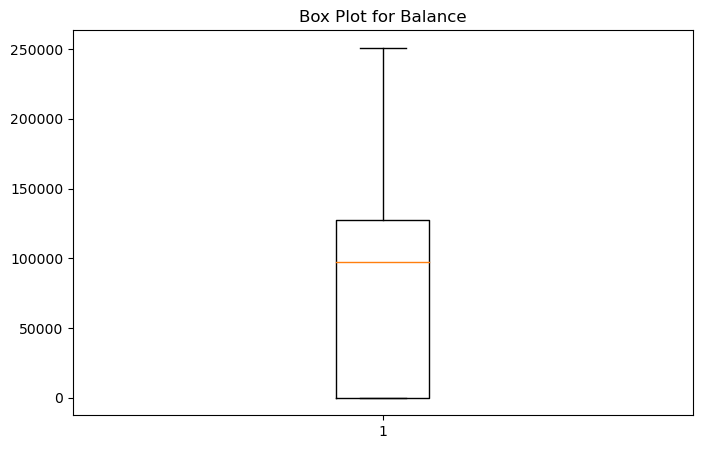

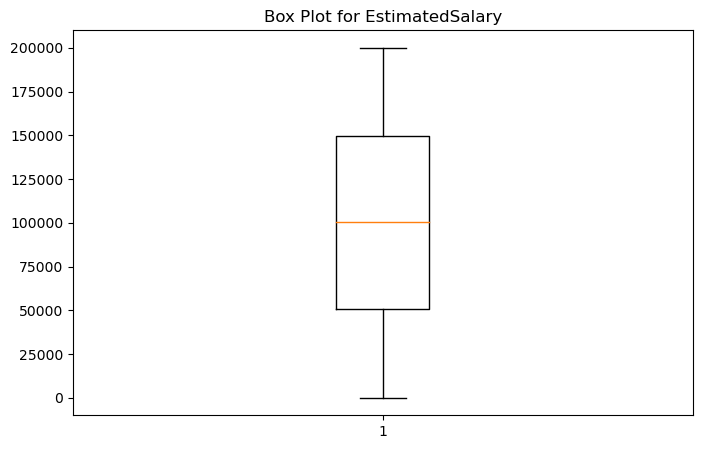

In [96]:
for col in numcol:
    plt.figure(figsize=(8, 5))  # Create a new figure for each plot
    plt.boxplot(emp[col])
    plt.title(f'Box Plot for {col}')
    plt.show()  # Display the plot and close it before the next one

There's seems to be outliers just for CreditScore and for Age, especially for this second one.

We can choose to maintain them or to study the IQR in order to manage the values exceeding this range. Let's see the IQR and where there are values exceeding the IQR we are going to change them with the nearest limit (the q1 or the q3)

---------------------------------------------------------------------------------------------------------------
**STEP 3: OUTLIERS**

In [97]:
outcol=["CreditScore","Age"]
for outlier in outcol:
    q1=emp[outlier].quantile(0.25)
    q3=emp[outlier].quantile(0.75)
    max_limit=q3+(1.5*(q3-q1))
    min_limit=q3-(1.5*(q3-q1))

    emp[outlier]=np.where(emp[outlier]<min_limit,min_limit,np.where(emp[outlier]>max_limit,max_limit,emp[outlier]))

---------------------------------------------------------------------------------------------------------------
**STEP 4: MISSING VALUES**

Now let's see the missing values

In [98]:
emp.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Oh my gosh there's no missing values!!

---------------------------------------------------------------------------------------------------------------
**STEP 5: CORRELATION & DUMMIES**

Now let's see the correlation between variables

In [99]:
#before correlation matrix, let's exclude columns we don't need, such as customerid, surname, rownumber and let's use dummy variables
#aka let's transform the categorical ones into dummies.
emp = emp.drop(['RowNumber','CustomerId','Surname'], axis=1)

In [100]:
emp_new = pd.get_dummies(emp, columns=['Geography','Gender'], drop_first=True)
emp_new.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619.0,42.0,2,0.00,1,1,1,101348.88,1,False,False,False
1,608.0,41.0,1,83807.86,1,0,1,112542.58,0,False,True,False
2,517.0,42.0,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699.0,39.0,1,0.00,2,0,0,93826.63,0,False,False,False
4,850.0,43.0,2,125510.82,1,1,1,79084.10,0,False,True,False


In [101]:
emp_new['Geography_Germany'] = emp_new['Geography_Germany'].replace({True:1,False:0})
emp_new['Geography_Spain'] = emp_new['Geography_Spain'].replace({True:1,False:0})
emp_new['Gender_Male'] = emp_new['Gender_Male'].replace({True:1,False:0})

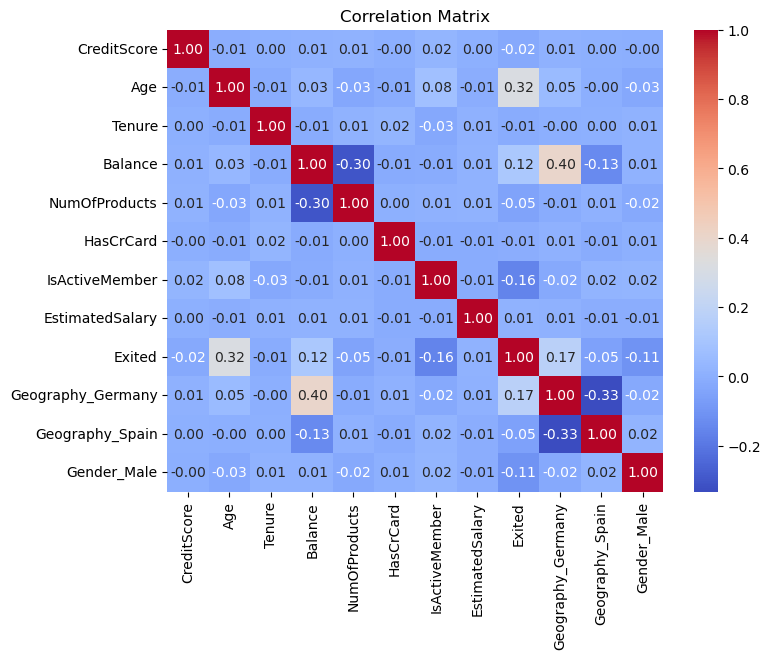

In [102]:
#let's see the correlation between the variables
corr_matrix = emp_new.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

All the correlation values are, in absolute terms, below 0.5, so we can decide to use all the variables for the moment.

---------------------------------------------------------------------------------------------------------------
**STEP 6: MODEL CHOOSING AND IMPLEMENTATION**

Ok, now we have to think about the model. We need to predict the Exited column, whether it will be 1 or 0.
Therefore, it is a classification problem. For this purpose, we can use different models, such as LogisticRegression or more sofisticated ones, as ClassificationGradientBoost or Support Vector Machine. Then we will evaluate and compare them. 

Before starting, let's see if the dataset is skewd or not

In [103]:
target_flag_1_percent = (emp_new["Exited"].sum()/emp_new["Exited"].count())*100
print(target_flag_1_percent)

20.369999999999997


It is skewed! Just 20% of the employees has gone from the company. Not bad. But we need to consider this fact for our model implementation.

Before going to model implementation, let's firstly standardize records

In [104]:
from sklearn.model_selection import train_test_split

X = emp_new.drop("Exited", axis=1)
y = emp_new["Exited"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [105]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

----------------**LOGISTIC REGRESSION**----------------

In [74]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train,y_train)

y_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:,1] # Probability of positive class

----------------**GRADIENT BOOSTING CLASSIFIER**----------------

In [59]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {'n_estimators': [50, 100, 200, 300],
             'learning_rate': [0.025, 0.05, 0.10, 0.5],
             'max_depth': [3, 5, 7, 10],
             'random_state': [42]}

gbc = GradientBoostingClassifier()

grid_search_class = GridSearchCV(gbc, param_grid, cv=5)
grid_search_class.fit(X_train, y_train)

print("The best hyperparameters for classification are:", grid_search_class.best_params_)
print("Best score:", grid_search_class.best_score_)

The best hyperparameters for classification are: {'learning_rate': 0.025, 'max_depth': 5, 'n_estimators': 200, 'random_state': 42}
Best score: 0.8632500000000001


In [75]:
gbc_best = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.025,
    max_depth=5,
    random_state=42
)
gbc_best.fit(X_train, y_train)

#Let's make predictions
y_gbc = gbc_best.predict(X_test)
y_proba_gbc = gbc_best.predict_proba(X_test)[:, 1] # Probability of positive class

----------------**SUPPORT VECTOR MACHINE**----------------

In [76]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, precision_recall_curve, auc

# Initialize SVM with class weights to handle imbalance
svm = SVC(class_weight='balanced', probability=True, random_state=42)

# Train
svm.fit(X_train, y_train)

# Predict probabilities and classes
y_svm = svm.predict(X_test)
y_proba_svm = svm.predict_proba(X_test)[:, 1]  # Probability of positive class

---------------------------------------------------------------------------------------------------------------
**STEP 7: MODEL EVALUATION**

Gradient Boosting Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.75      0.48      0.58       393

    accuracy                           0.87      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000

AUC Score: 0.8717158234251865


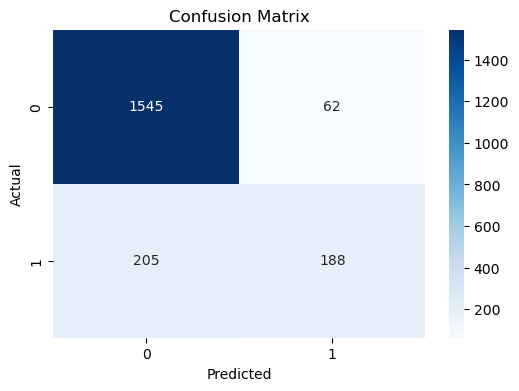

SVM Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.79      0.85      1607
           1       0.47      0.75      0.58       393

    accuracy                           0.78      2000
   macro avg       0.70      0.77      0.72      2000
weighted avg       0.84      0.78      0.80      2000

SVM PR-AUC: 0.656


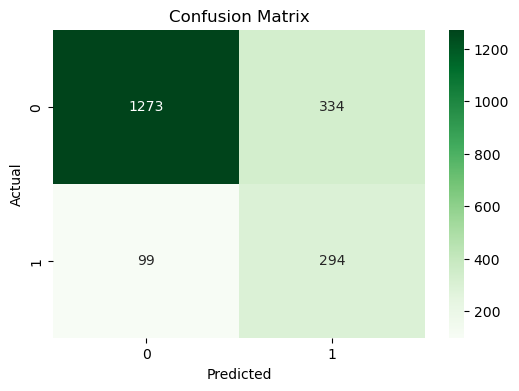

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.96      0.89      1607
           1       0.59      0.24      0.34       393

    accuracy                           0.82      2000
   macro avg       0.71      0.60      0.62      2000
weighted avg       0.79      0.82      0.79      2000

Logistic Regression PR-AUC: 0.505


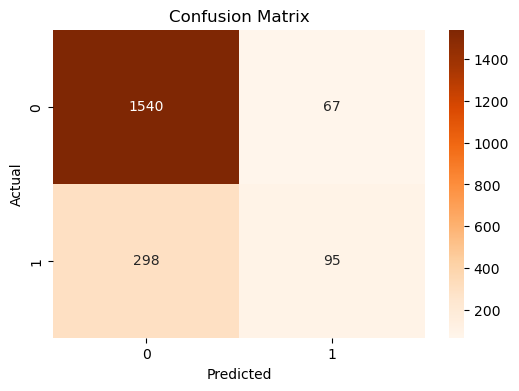

In [77]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, mean_squared_error, mean_absolute_error

#Let's evaluate the Gradient Boosting model
print("Gradient Boosting Classification Report:\n", classification_report(y_test, y_gbc))
print("AUC Score:", roc_auc_score(y_test, y_proba_gbc))

#Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_gbc), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


#Let's evaluate the SVM model
print("SVM Classification Report:\n", classification_report(y_test, y_svm))

# Compute PR-AUC
precision_svm, recall_svm, _ = precision_recall_curve(y_test, y_proba_svm)
pr_auc_svm = auc(recall_svm, precision_svm)
print(f"SVM PR-AUC: {pr_auc_svm:.3f}")

#Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_svm), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#Let's evaluate the Logistic Regression model
print("Logistic Regression Classification Report:\n", classification_report(y_test, y_lr))

# Compute PR-AUC
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_proba_lr)
pr_auc_lr = auc(recall_lr, precision_lr)
print(f"Logistic Regression PR-AUC: {pr_auc_lr:.3f}")

#Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_lr), annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

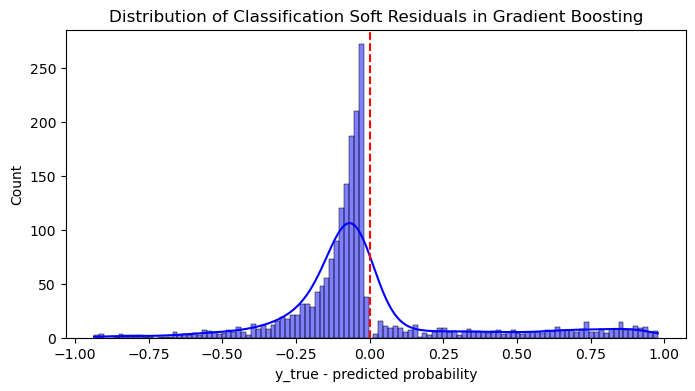

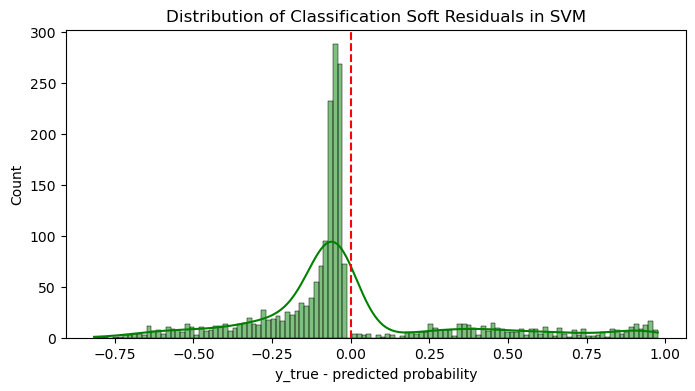

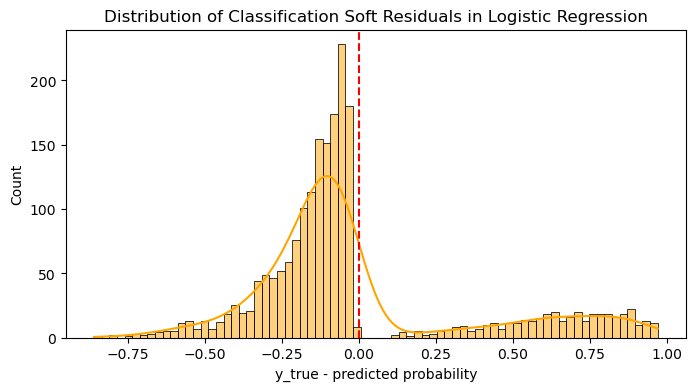

In [78]:
#Let's see the residuals for the classification problem
soft_residuals_gbc = y_test - y_proba_gbc
soft_residuals_svm = y_test - y_proba_svm
soft_residuals_lr = y_test - y_proba_lr

plt.figure(figsize=(8, 4))
sns.histplot(soft_residuals_gbc, kde=True, color='blue')
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribution of Classification Soft Residuals in Gradient Boosting")
plt.xlabel("y_true - predicted probability")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(soft_residuals_svm, kde=True, color='green')
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribution of Classification Soft Residuals in SVM")
plt.xlabel("y_true - predicted probability")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(soft_residuals_lr, kde=True, color='orange')
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribution of Classification Soft Residuals in Logistic Regression")
plt.xlabel("y_true - predicted probability")
plt.show()

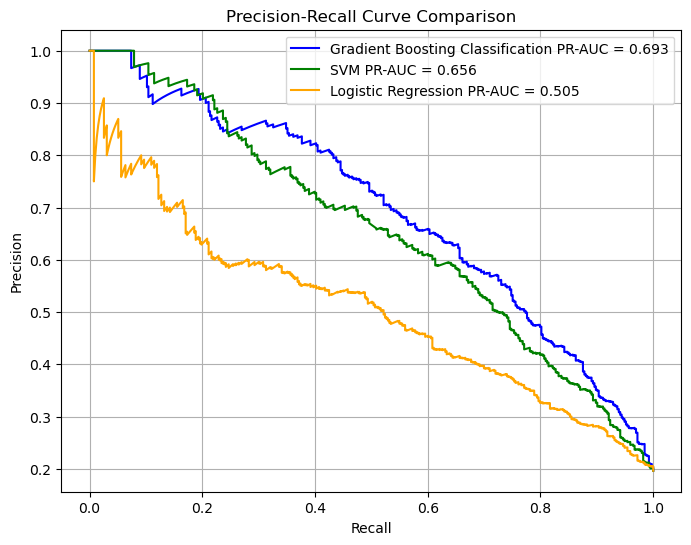

In [79]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_proba_gbc)
pr_auc = average_precision_score(y_test, y_proba_gbc)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Gradient Boosting Classification PR-AUC = {pr_auc:.3f}', color='blue')
plt.plot(recall_svm, precision_svm, 
         label=f'SVM PR-AUC = {pr_auc_svm:.3f}', color='green')
plt.plot(recall_lr, precision_lr, label=f'Logistic Regression PR-AUC = {pr_auc_lr:.3f}', color='orange')

plt.xlabel('Recall')

plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend(loc='best')
plt.grid(True)
plt.show()

In addition to standard metrics, the **Brier score** is useful when evaluating the quality of predicted probabilities rather than hard class predictions. It **measures the mean squared difference between predicted probabilities and the actual binary outcomes** (0 or 1), making it especially relevant for models where well-calibrated probabilities are important—such as in risk scoring, weather forecasting, or medical decision-making. A lower Brier score indicates better probabilistic accuracy. Unlike accuracy or F1-score, the Brier score rewards models that not only classify correctly but are also confident and calibrated in their predictions. However, it is not ideal for highly imbalanced datasets, as it can be dominated by the majority class unless adjustments or stratified evaluations are made. By the way, let's try it and see what value we obtain.

In [80]:
from sklearn.metrics import brier_score_loss

BS_gbc = brier_score_loss(y_test, y_proba_gbc)
BS_svm = brier_score_loss(y_test, y_proba_svm)
BS_lr = brier_score_loss(y_test, y_proba_lr)

print(f"Gradient Boosting Classifier Brier Score: {BS_gbc:.2f}")
print(f"SVM Brier Score: {BS_svm:.2f}")
print(f"Logistic Regression Brier Score: {BS_lr:.2f}")

Gradient Boosting Classifier Brier Score: 0.10
SVM Brier Score: 0.11
Logistic Regression Brier Score: 0.13


the baseline score would be

            Baseline Brier = (1-0.2)^2 * 0.2 + (0 - 0.2)^2 * (1-0.2) = 0.16
 
And since 0.10<0.16, Gradient Boosting improves the baseline score and outperformes also the Logistic Regression and the SVM models, even though each model does better than random guessing.

---------------------------------------------------------------------------------------------------------------
**STEP 8: MODEL EXPLANATION**

Age                  0.357655
NumOfProducts        0.262734
IsActiveMember       0.118476
Balance              0.106650
Geography_Germany    0.053577
EstimatedSalary      0.050215
CreditScore          0.023377
Gender_Male          0.012570
Tenure               0.011433
Geography_Spain      0.002661
HasCrCard            0.000652
dtype: float64


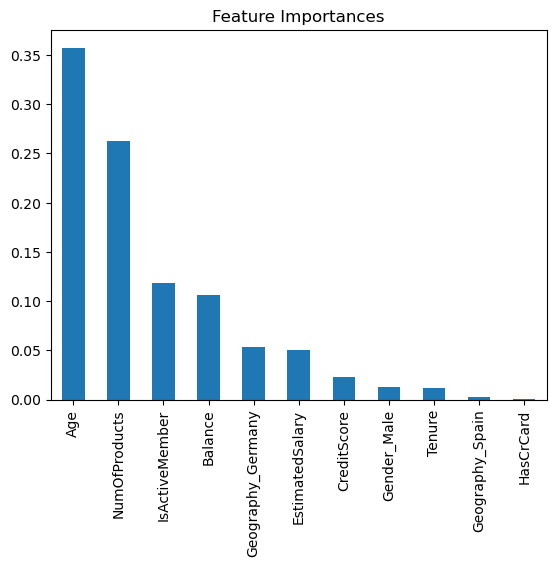

In [112]:
feature_importances = gbc_best.feature_importances_

feat_importances = pd.Series(feature_importances, index=X.columns)
feat_importances = feat_importances.sort_values(ascending=False)
print(feat_importances)

# Visualization
feat_importances.plot(kind='bar')
plt.title('Feature Importances')
plt.show()